In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor

In [2]:
df = pd.read_csv('dataset2.csv')

In [3]:
import datetime  
import time  
  

timestamp = []  
for d, t in zip(df['Date'], df['Time']):  
    try:  
        ts = datetime.datetime.strptime(d+' '+t, "%Y/%m/%d %H:%M:%S.%f")
        ts = ts.replace(microsecond=0)  
        timestamp.append(time.mktime(ts.timetuple()))  
    except OverflowError:  
        timestamp.append('ValueError')  

timeStamp = pd.Series(timestamp)  
df['Timestamp'] = timeStamp.values.astype(str)

df_final = df.drop(['Gap','Magt'], axis=1)
df_final = df_final[df_final.Timestamp != 'ValueError']

In [4]:
df_final['Timestamp'] = df_final['Timestamp'].str.strip()

In [5]:
df_final['Timestamp'] = df_final['Timestamp'].astype(float)

In [6]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17841 entries, 189 to 18029
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             17841 non-null  object 
 1   Time             17841 non-null  object 
 2   Latitude         17841 non-null  float64
 3   Longitude        17841 non-null  float64
 4   Depth            17841 non-null  float64
 5   Magnitude        17841 non-null  float64
 6   No stations      17841 non-null  int64  
 7   Dist to Closest  17841 non-null  int64  
 8   RMS              17841 non-null  float64
 9   SRC              17841 non-null  object 
 10  EventID          17841 non-null  int64  
 11  Timestamp        17841 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 1.8+ MB


In [7]:
split_index = int(len(df) * 0.9)

# Create subsets
subset1 = df_final.iloc[:split_index]  # First 90%
subset2 = df_final.iloc[split_index:]  # Remaining 10%

df_final = subset1

In [7]:
X = df_final[['Timestamp','Latitude','Longitude','Depth']]
y = df_final[['Magnitude']]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train

,Timestamp,Latitude,Longitude,Depth
7148,4.213521e+08,36.2253,-120.2897,8.96
8887,5.223773e+08,37.5333,-118.4087,7.22
2977,1.649967e+08,40.5140,-125.0725,8.50
16499,1.019123e+09,38.7908,-122.7742,3.08
4691,3.078811e+08,38.7953,-122.8082,4.78
...,...,...,...,...
11473,6.979289e+08,40.4478,-125.1805,4.38
12153,7.195517e+08,35.9283,-120.4740,10.08
5579,3.401997e+08,37.4588,-118.8372,11.18
1049,6.823795e+07,36.5365,-121.0832,9.43


In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14272 entries, 7148 to 15984
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  14272 non-null  float64
 1   Latitude   14272 non-null  float64
 2   Longitude  14272 non-null  float64
 3   Depth      14272 non-null  float64
dtypes: float64(4)
memory usage: 557.5 KB


In [11]:
# Scale the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
def create_model(neurons, activation, optimizer, loss):  
    model = Sequential() 
    model.add(layers.Input((4,)))
    model.add(layers.Dense(neurons, activation=activation))  
    # model.add(layers.Dropout(0.4))
    model.add(layers.Dense(neurons, activation=activation))  
    # model.add(layers.Dense(neurons, activation=activation))  
    model.add(layers.Dense(1))  
      
    model.compile(optimizer=optimizer, loss=loss, metrics=['mae'])  
      
    return model  

In [13]:
# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='loss',          # Metric to monitor (could also be 'val_loss')
    patience=10,              # Number of epochs with no improvement before stopping
    restore_best_weights=True  # Restore the weights of the best epoch
)

In [44]:
model_keres = KerasRegressor(model=create_model, verbose=0)
  
neurons = [16, 64, 128]  
batch_size = [20, 50, 100]  
epochs = [60]  
activation = ['relu']  
optimizer = ['adam','SGD', 'RMSProp']  
loss = ['mean_absolute_error','mean_squared_error'] 
callback = [[early_stopping]] 
  
param_grid = dict(model__neurons=neurons, batch_size=batch_size, epochs=epochs, model__activation=activation, model__optimizer=optimizer, model__loss=loss, callbacks=callback)  

In [40]:
param_grid

{'model__neurons': [16, 64, 128],
 'batch_size': [20, 50, 100],
 'epochs': [20],
 'model__activation': ['relu'],
 'model__optimizer': ['adam', 'SGD', 'RMSProp'],
 'model__loss': ['mean_absolute_error', 'mean_squared_error'],
 'callbacks': [[<keras.src.callbacks.early_stopping.EarlyStopping at 0x1eb85cb9eb0>]]}

In [41]:
# Initialize GridSearchCV
grid = GridSearchCV(estimator=model_keres, 
                    param_grid=param_grid, 
                    scoring='neg_mean_absolute_error' # Use MAE for regression
                    )  # 3-fold cross-validation

In [42]:
grid_result = grid.fit(X_train, y_train)  

c:\Users\Piotr\Desktop\Studia\Introduction to ML\Earthquake_detection\Earthquake\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Piotr\Desktop\Studia\Introduction to ML\Earthquake_detection\Earthquake\Lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Piotr\Desktop\Studia\Introduction to ML\Earthquake_detection\Earthquake\Lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Piotr\Desktop\Studia\Introduction to ML\Earthquake_detection\Ear

In [43]:
print("Best Parameters:", grid_result.best_params_)

Best Parameters: {'batch_size': 20, 'callbacks': [<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000001EB85CB9EB0>], 'epochs': 20, 'model__activation': 'relu', 'model__loss': 'mean_absolute_error', 'model__neurons': 64, 'model__optimizer': 'adam'}


In [53]:
print("Best Score:", grid_result.best_score_)

Best Score: -0.30943461850172993


In [ ]:
best_par = {'batch_size': 20, 'callbacks': [[]], 
            'epochs': 20, 'model__activation': 'relu', 'model__loss': 'mean_absolute_error', 'model__neurons': 64, 'model__optimizer': 'adam'}

In [21]:
model_2 = create_model(64, 'relu', Adam(learning_rate=0.0001), 'mean_squared_error')

Epoch 1/400


357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.8078 - mae: 2.8982 - val_loss: 1.3256 - val_mae: 0.9915
Epoch 2/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7774 - mae: 0.6974 - val_loss: 0.3462 - val_mae: 0.4635
Epoch 3/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3535 - mae: 0.4568 - val_loss: 0.2392 - val_mae: 0.3689
Epoch 4/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2605 - mae: 0.3754 - val_loss: 0.2087 - val_mae: 0.3405
Epoch 5/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2331 - mae: 0.3534 - val_loss: 0.2004 - val_mae: 0.3296
Epoch 6/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2280 - mae: 0.3487 - val_loss: 0.1962 - val_mae: 0.3304
Epoch 7/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2121 - mae: 0.3377 - val_loss: 0.1923 - val_mae: 0.3271
Epoch 8/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2080 - mae: 0.3322 - val_loss: 0.1908 - val_mae: 0.3321
Epoch 9/400
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss:

<Axes: title={'center': 'Mean absolute error'}>

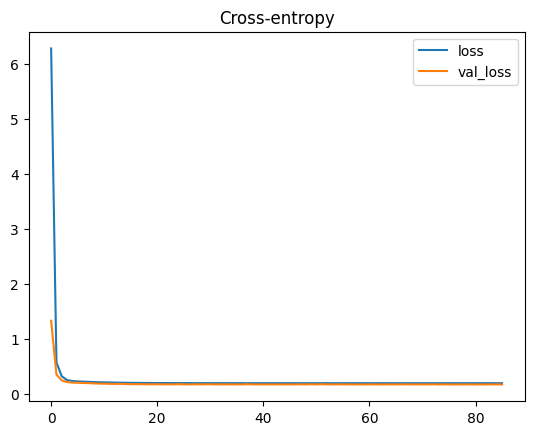

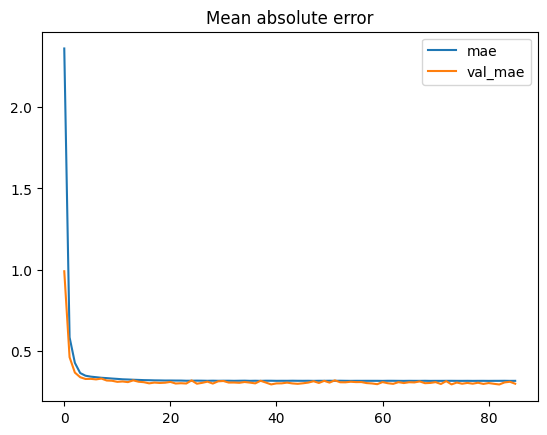

In [22]:
history = model_2.fit(
    X_train_scaled, y_train,
    validation_data = (X_test_scaled, y_test),
    batch_size = 40,
    epochs = 400,
    callbacks=[early_stopping],
    verbose = 1
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['mae', 'val_mae']].plot(title="Mean absolute error")

In [54]:
history_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   loss      149 non-null    float64
 1   mae       149 non-null    float64
 2   val_loss  149 non-null    float64
 3   val_mae   149 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [16]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model_2.evaluate(X_test, y_test, batch_size=128)
print("test loss, test mae:", results)

Evaluate on test data
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 286591588430249984.0000 - mae: 463215616.0000 
test loss, test mae: [2.872235670980526e+17, 463482528.0]


In [23]:
y_pred = model_2.predict(X_test_scaled)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [24]:
y_pred[:,0]

array([3.35242  , 3.6421778, 3.353902 , ..., 3.2927313, 3.3704138,
       3.4047444], dtype=float32)

In [25]:
y_train

,Magnitude
7148,3.12
8887,3.07
2977,3.20
16499,3.54
4691,3.18
...,...
11473,3.06
12153,4.36
5579,3.67
1049,4.49


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 0.30
Mean Squared Error: 0.17
R-squared: 0.03
